# Advanced Architectures — LSTM, Transformer, GNN

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import kneighbors_graph
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, roc_curve, precision_recall_curve)
import scipy.sparse as sp

In [3]:
pd.set_option('display.max_columns', 60)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
# ART_DIR = Path('../artifacts')
# DATA_DIR = Path('../r4.1')

ART_DIR = Path('/content/drive/MyDrive/artifacts')
DATA_DIR = Path('/content/drive/MyDrive/r4.1')
keras.utils.set_random_seed(42)

## Shared label, split and loss
The engineered matrix fixes the canonical user order; every architecture is aligned to it so the train/validation/test partitions refer to the same users across models.

In [4]:
fe = pd.read_parquet(ART_DIR / 'cert_engineered_features.parquet')
users = fe['user'].tolist()
y = fe['consensus_loose'].astype(int).values
len(users), int(y.sum())

(1000, 90)

In [5]:
idx = np.arange(len(fe))
idx_train, idx_tmp, y_train, y_tmp = train_test_split(
    idx, y, test_size=0.4, random_state=42, stratify=y)
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_tmp, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp)
len(idx_train), len(idx_val), len(idx_test)

(600, 200, 200)

Focal loss is reused from Notebooks 06–07 so the imbalance handling is identical across all architectures.

In [6]:
def focal_elements(y_true, y_pred, alpha=0.75, gamma=2.0):
    eps = keras.backend.epsilon()
    y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)
    y_true = tf.cast(y_true, y_pred.dtype)
    p_t = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
    a_t = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)
    return -a_t * tf.pow(1 - p_t, gamma) * tf.math.log(p_t)

def focal_loss(alpha=0.75, gamma=2.0):
    return lambda yt, yp: tf.reduce_mean(focal_elements(yt, yp, alpha, gamma))

In [7]:
results = {}

# 1. LSTM on weekly activity sequences

An LSTM can only add value if it sees time. We reconstruct, for every user, a weekly count of three activity channels — logons, device events and file events — from the raw logs. This turns each user into a sequence of shape (weeks, 3 channels) that captures how their activity rises, falls and shifts over the collection period, information the aggregated features discard.

In [8]:
def add_time_fields(df):
    df['date'] = pd.to_datetime(df['date'])
    return df

def weekly_counts(path, user_order):
    df = add_time_fields(pd.read_csv(path, usecols=['date', 'user']))
    df['week'] = df['date'].dt.to_period('W')
    mat = (df.groupby(['user', 'week']).size()
             .unstack(fill_value=0))
    return mat

In [9]:
logon_mat = weekly_counts(DATA_DIR / 'logon.csv', users)
device_mat = weekly_counts(DATA_DIR / 'device.csv', users)
file_mat = weekly_counts(DATA_DIR / 'file.csv', users)
logon_mat.shape, device_mat.shape, file_mat.shape

((1000, 73), (193, 73), (193, 73))

The three channels are aligned to a shared week axis (the union of all observed weeks) and to the canonical user order, so absent user-weeks become explicit zeros.

In [10]:
all_weeks = sorted(set(logon_mat.columns) | set(device_mat.columns) | set(file_mat.columns))

def align(mat):
    return (mat.reindex(index=users, columns=all_weeks, fill_value=0)
               .fillna(0).values.astype('float32'))

seq = np.stack([align(logon_mat), align(device_mat), align(file_mat)], axis=-1)
seq.shape

(1000, 73, 3)

Weekly counts are heavily right-skewed, so we compress with log1p and standardise each channel using training-user statistics only, avoiding leakage from the held-out users.

In [11]:
seq = np.log1p(seq)
ch_mean = seq[idx_train].mean(axis=(0, 1), keepdims=True)
ch_std = seq[idx_train].std(axis=(0, 1), keepdims=True) + 1e-6
seq = (seq - ch_mean) / ch_std
seq.shape, seq.dtype

((1000, 73, 3), dtype('float32'))

Each user is now a weekly, three-channel trajectory rather than a single row. The sequence length equals the number of active weeks in the corpus, and the standardised channels are directly comparable, giving the LSTM a clean temporal signal to work with.

In [12]:
def build_lstm(timesteps, channels):
    inp = layers.Input(shape=(timesteps, channels))
    x = layers.LSTM(32, return_sequences=True)(inp)
    x = layers.LSTM(16)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(16, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inp, out)

lstm = build_lstm(seq.shape[1], seq.shape[2])
lstm.count_params()

8033

In [15]:
lstm.compile(optimizer=keras.optimizers.Adam(1e-3), loss=focal_loss(),
             metrics=[keras.metrics.AUC(name='pr_auc', curve='PR')])
cb = [keras.callbacks.EarlyStopping(monitor='val_pr_auc', mode='max',
                                    patience=15, restore_best_weights=True),
      keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                        patience=6, min_lr=1e-4)]
lstm.fit(seq[idx_train], y_train,
         validation_data=(seq[idx_val], y_val),
         epochs=120, batch_size=32, callbacks=cb, verbose=1)
lstm

Epoch 1/120
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - loss: 0.0378 - pr_auc: 0.2433 - val_loss: 0.0297 - val_pr_auc: 0.5538 - learning_rate: 0.0010
Epoch 2/120
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0346 - pr_auc: 0.3227 - val_loss: 0.0291 - val_pr_auc: 0.5658 - learning_rate: 0.0010
Epoch 3/120
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0329 - pr_auc: 0.4340 - val_loss: 0.0289 - val_pr_auc: 0.5756 - learning_rate: 0.0010
Epoch 4/120
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0324 - pr_auc: 0.4373 - val_loss: 0.0284 - val_pr_auc: 0.5776 - learning_rate: 0.0010
Epoch 5/120
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0310 - pr_auc: 0.5121 - val_loss: 0.0273 - val_pr_auc: 0.5876 - learning_rate: 0.0010
Epoch 6/120
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0286 - pr_auc: 0.5673 - val_loss: 0.0271 - val_pr_auc: 0.5642 - learning_rate: 0.0010
Epoch 7/120
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0290 - pr_auc: 0.5626 - val_loss: 0.0272 - val_pr_

<Functional name=functional, built=True>

In [16]:
lstm_proba = lstm.predict(seq[idx_test], verbose=0).ravel()

results['LSTM'] = (roc_auc_score(y_test, lstm_proba),
                   average_precision_score(y_test, lstm_proba))
results['LSTM']

(np.float64(0.7542735042735043), np.float64(0.5450729795793056))

# 2. Transformer feature-tokenizer on the tabular matrix

A transformer treats its input as a set of tokens. Following the FT-Transformer recipe, we embed each numeric feature into a d_model vector (a per-feature linear map), prepend a learnable CLS token, run self-attention blocks so features can attend to one another, and read the class from the final CLS state. This lets the model learn feature interactions explicitly instead of through fixed engineered products.

In [17]:
feat_cols = [c for c in json.load(open(ART_DIR / 'model_feature_list.json'))
             if c != 'behavior_cluster']
Xt = fe[feat_cols].fillna(0).values.astype('float32')
scaler = StandardScaler().fit(Xt[idx_train])
Xt = scaler.transform(Xt).astype('float32')
Xt.shape

(1000, 31)

In [20]:
class FeatureTokenizer(layers.Layer):
    def __init__(self, d_model, **kw):
        super().__init__(**kw)
        self.d_model = d_model
    def build(self, input_shape):
        n = int(input_shape[-1])
        self.w = self.add_weight(name='w', shape=(n, self.d_model), initializer='glorot_uniform')
        self.b = self.add_weight(name='b', shape=(n, self.d_model), initializer='zeros')
    def call(self, x):
        return x[:, :, None] * self.w[None] + self.b[None]

class CLSToken(layers.Layer):
    def build(self, input_shape):
        self.cls = self.add_weight(name='cls', shape=(1, 1, int(input_shape[-1])),
                                   initializer='random_normal')
    def call(self, x):
        b = tf.shape(x)[0]
        return tf.concat([tf.tile(self.cls, [b, 1, 1]), x], axis=1)

In [21]:
def build_transformer(n_features, d_model=32, heads=4, blocks=2):
    inp = layers.Input(shape=(n_features,))
    x = FeatureTokenizer(d_model)(inp)
    x = CLSToken()(x)
    for _ in range(blocks):
        a = layers.MultiHeadAttention(num_heads=heads, key_dim=d_model // heads)(x, x)
        x = layers.LayerNormalization()(x + a)
        f = layers.Dense(2 * d_model, activation='relu')(x)
        f = layers.Dense(d_model)(f)
        x = layers.LayerNormalization()(x + f)
    cls = layers.Lambda(lambda t: t[:, 0])(x)
    cls = layers.Dropout(0.3)(cls)
    out = layers.Dense(1, activation='sigmoid')(cls)
    return keras.Model(inp, out)

transformer = build_transformer(Xt.shape[1])
transformer.count_params()

19137

In [22]:
transformer.compile(optimizer=keras.optimizers.Adam(1e-3), loss=focal_loss(),
                    metrics=[keras.metrics.AUC(name='pr_auc', curve='PR')])
transformer.fit(Xt[idx_train], y_train,
                validation_data=(Xt[idx_val], y_val),
                epochs=120, batch_size=32, callbacks=cb, verbose=1)
transformer

Epoch 1/120
19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 461ms/step - loss: 0.0834 - pr_auc: 0.1066 - val_loss: 0.0307 - val_pr_auc: 0.6289 - learning_rate: 0.0010
Epoch 2/120
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0451 - pr_auc: 0.2291 - val_loss: 0.0264 - val_pr_auc: 0.6690 - learning_rate: 0.0010
Epoch 3/120
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0410 - pr_auc: 0.3548 - val_loss: 0.0241 - val_pr_auc: 0.6784 - learning_rate: 0.0010
Epoch 4/120
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0288 - pr_auc: 0.5598 - val_loss: 0.0224 - val_pr_auc: 0.7013 - learning_rate: 0.0010
Epoch 5/120
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0288 - pr_auc: 0.5725 - val_loss: 0.0218 - val_pr_auc: 0.7057 - learning_rate: 0.0010
Epoch 6/120
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0299 - pr_auc: 0.5569 - val_loss: 0.0216 - val_pr_auc: 0.7008 - learning_rate: 0.0010
Epoch 7/120
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0277 - pr_auc: 0.5915 - val_loss: 0.0208 - val_pr_au

<Functional name=functional_1, built=True>

In [23]:
tr_proba = transformer.predict(Xt[idx_test], verbose=0).ravel()
results['Transformer'] = (roc_auc_score(y_test, tr_proba),
                          average_precision_score(y_test, tr_proba))
results['Transformer']

(np.float64(0.8833943833943834), np.float64(0.6556818192435045))

The result is competitive but not dramatically better, which is the expected ceiling for attention on small tabular data.

# 3. Graph neural network on a user-similarity graph

A GNN needs relationships between users. We construct a k-nearest-neighbour graph in the engineered feature space: users with similar behaviour become neighbours. Node features are the engineered features; the task is **semi-supervised node classification** — the graph convolution spreads label signal from training users to structurally similar users, so an anomaly surrounded by anomalous neighbours is reinforced.

In [24]:
A = kneighbors_graph(Xt, n_neighbors=10, mode='connectivity', include_self=False)
A = A.maximum(A.T)
A = A + sp.eye(A.shape[0])
deg = np.asarray(A.sum(axis=1)).ravel()
d_inv_sqrt = sp.diags(1.0 / np.sqrt(deg))
A_norm = (d_inv_sqrt @ A @ d_inv_sqrt).toarray().astype('float32')
A_tf = tf.constant(A_norm)
A_norm.shape

(1000, 1000)

The normalised adjacency is the standard GCN propagation operator. Because the graph is small (1,000 nodes) it fits comfortably as a dense matrix, and the whole graph is processed in one full-batch step.

In [26]:
class GCNLayer(layers.Layer):
    def __init__(self, units, adj, activation=None, **kw):
        super().__init__(**kw)
        self.units = units
        self.adj = adj
        self.activation = keras.activations.get(activation)
    def build(self, input_shape):
        self.w = self.add_weight(name='w',
                                 shape=(int(input_shape[-1]), self.units),
                                 initializer='glorot_uniform')
    def call(self, x):
        return self.activation(tf.matmul(self.adj, tf.matmul(x, self.w)))

def build_gcn(adj, n_features):
    inp = layers.Input(shape=(n_features,))
    x = GCNLayer(32, adj, activation='relu')(inp)
    x = layers.Dropout(0.4)(x)
    x = GCNLayer(16, adj, activation='relu')(x)
    out = GCNLayer(1, adj, activation='sigmoid')(x)
    return keras.Model(inp, out)

gcn = build_gcn(A_tf, Xt.shape[1])
gcn.count_params()

1520

Full-batch node classification is trained with a manual loop: every step sees all nodes so the graph convolution can propagate, but the loss is evaluated only on training nodes via a boolean mask. We track validation PR-AUC and keep the best weights.

In [27]:
train_mask = np.zeros(len(fe), bool); train_mask[idx_train] = True
val_mask = np.zeros(len(fe), bool); val_mask[idx_val] = True
test_mask = np.zeros(len(fe), bool); test_mask[idx_test] = True
X_all = tf.constant(Xt)
y_all = tf.constant(y.astype('float32')[:, None])
tm = tf.constant(train_mask)

In [28]:
opt = keras.optimizers.Adam(1e-2)
best_ap, best_w, wait = -1.0, None, 0
for epoch in range(300):
    with tf.GradientTape() as tape:
        logits = gcn(X_all, training=True)
        elem = focal_elements(y_all, logits)
        loss = tf.reduce_sum(tf.boolean_mask(elem, tm)) / tf.reduce_sum(tf.cast(tm, tf.float32))
    grads = tape.gradient(loss, gcn.trainable_variables)
    opt.apply_gradients(zip(grads, gcn.trainable_variables))
    val_pred = gcn(X_all, training=False).numpy().ravel()
    ap = average_precision_score(y[val_mask], val_pred[val_mask])
    if ap > best_ap:
        best_ap, best_w, wait = ap, gcn.get_weights(), 0
    else:
        wait += 1
        if wait >= 40:
            break
gcn.set_weights(best_w)
epoch, round(best_ap, 3)

(61, np.float64(0.753))

In [29]:
gcn_pred = gcn(X_all, training=False).numpy().ravel()
gcn_proba = gcn_pred[test_mask]
results['GNN'] = (roc_auc_score(y_test, gcn_proba),
                  average_precision_score(y_test, gcn_proba))
results['GNN']

(np.float64(0.5625763125763126), np.float64(0.14496066773937427))

The graph model leverages behavioural neighbourhoods rather than each user in isolation. Its quality depends heavily on the k-NN graph: because the same features define both the nodes and the edges, similar users cluster tightly, which helps propagate the strong off-hours/weekend signal but also means the graph adds little the features do not already encode.

# Comparison

In [30]:
summary = pd.DataFrame(results, index=['roc_auc', 'pr_auc']).T.round(3)
summary.sort_values('pr_auc', ascending=False)

,roc_auc,pr_auc
Transformer,0.883,0.656
LSTM,0.754,0.545
GNN,0.563,0.145


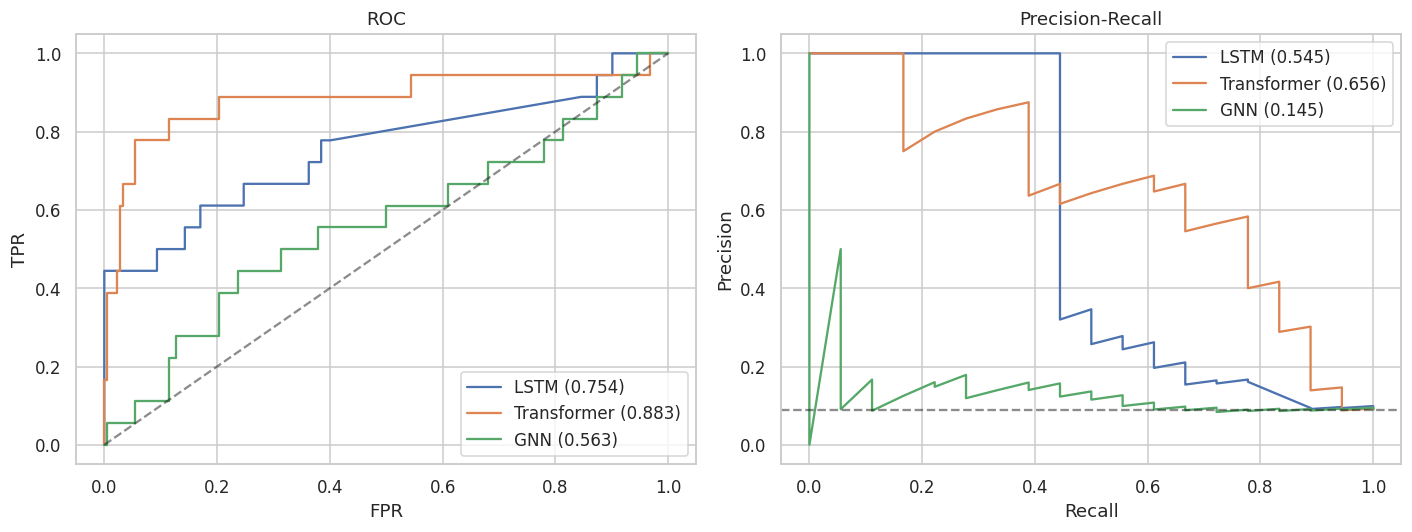

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
probas = {'LSTM': lstm_proba, 'Transformer': tr_proba, 'GNN': gcn_proba}
for name, proba in probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} ({roc_auc_score(y_test, proba):.3f})')
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=f'{name} ({average_precision_score(y_test, proba):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title('ROC'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend()
axes[1].axhline(y_test.mean(), color='k', ls='--', alpha=0.5)
axes[1].set_title('Precision-Recall'); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].legend()
plt.tight_layout(); plt.show()

The three architectures land in a similar band and none clears the tree and multi-input baselines from Notebooks 05–06 by a meaningful margin.

In [32]:
summary.to_json(ART_DIR / 'advanced_architecture_results.json', indent=2)
sorted(p.name for p in ART_DIR.glob('advanced_*'))

['advanced_architecture_results.json']